### Respostas das perguntas do pdf

1. Acurácia e desvio padrão para generalização, matriz de confusão e curva ROC para entender o comportamento

2.  
- **Árvore de Decisão**  
Vantagens: Alta interpretabilidade; não exige normalização/padronização dos dados; rápido para previsões.  
Desvantagens: maior probabilidade de overfitting - árvores mais profundas são mais sensíveis a ruídos; tende a favorecer a classe com maior quantidade de amostras  
- **Naive Bayes**  
Vantagens: eficaz para bases menores (precisa de menos dados); funciona bem idependente da quantidade de features.  
Desvantages: o modelo pode ser prejudicado se as features forem muito relacionadas; não lida bem com novas categorias (atribui a probabilidade 0); má calibração de probabilidades.
- **KNN**  
Vantagens: simples de implementar; não faz suposições sobre a distribuição de dados; facilidade de processar novos dados; flexível para fronteiras lineares ou não lineares (complexas).   
Desvantagens: previsão lenta por conta da quantidade de cálculos de distância entre pontos; perda de eficiência com o aumento do número de features; sensível a escalas; mal ajuste do K pode influenciar negativamente o desempenho.
- **SVM**  
Vantagens: alto poder de modelamento de fronteiras não lineares; memória eficiente por utilizar subconjuntos dos pontos de treinamento; menos propendo a overfitting pela regularização de margem.  
Desvantagens: treinamento caro e lento para datasets grandes; sensível a hiperparâmetros; difícil interpretabilidade do resultado; maior necessidade de calibração.
- **Perceptron**  
Vantagens: simples implementação; rápido em treinamento e previsão (por ser linear); aprendizado "melhorado" com a atualização dos pesos.  
Desvantagens: limitações para classificar dados não lineares; baixa convergência se os dados não forem linearmente separáveis; básico para aplicações mais complexas (não prevê bem).

3. As variáveis devem ser normalizadas para a base de treino dos modelos KNN e SVM que são sensíveis a escalas e para o perceptron, pois redes neurais funcionam melhor quando os dados estão nas mesmas dimensões.

4. Por se tratar de uma base de dados reduzida, optou-se por utilizar uma validação cruzada estratificada (Stratified k-Fold), para que os resultados não tenham um viés ou uma alta variância. Desse modo, espera-se preservar a proporção das classes. Para o treinamento, será feita uma divisão em 5 grupos de dados, e cada modelo será treinado da maneira mais parecida possível, fazendo 5 treinos da validação cruzada.

5. Como os modelos já serão treinados com a validação cruzada, e os modelos têm poucos hiperparâmetros principais, caso seja necessário, será aplicado outro método de validação cruzada chamado Grid Search com Cross-Validation (GridSearchCV), que usa toda a base em rodízio para treinar e validar (sem desperdiçar amostras), mantém a proporção das classes (estratificada) e permite um controle fino dos hiperparâmetros críticos.

6. Como o dataset é pequeno, a melhor opção que não descarta entradas é implementar técnicas de redimensionamento de pesos, adotando as métricas adequadas para avaliar possíveis mudanças ou melhorias. Para isso, pode-se utilizar o argumento "class_weight='balanced'" para os modelos de Árvore de decisão, SVM e Perceptron, a fim de ajustar automaticamento os pesos com base na frequência.

7. Tendo em vista que os modelos já serão treinados com uma técnica que "tenta evitar" overfitting, pode-se plotar as curvas de aprendizado para entender como os erros estão se comportando, conseguindo, assim, diferenciar um overfitting (se o erro de treino for muito menor que o de validação) ou underfitting (se ambos forem altos)

8.  
 - **Perda de performance na destilação**: configurações incorretas resultando rendimentos baixos ou inadequados

 - **Baixa confiabilidade**: não ter certeza das previsões realizadas pelos modelos

 - **Erros de falso positivo ou falso negatico**: classificar C1 como C2 e vice-versa.

 - **Contaminação dos produtos**: pode ser um resultado dos erros de classificação, fazendo com que os lotes sejam perdidos.



9. Padronizar o treinamento para os diferentes modelos, ou seja, treiná-los da maneira mais próxima possível. Avaliar as métricas de desempenho resultantes de cada modelo, assim como as matrizes de confusão e as curvas ROC.

10.  
A interpretabilidade é importante, mas não deve ser o único critério de escolha.
O ideal é equilibrar transparência e desempenho, usando modelos explicáveis para compreender os dados e modelos mais complexos para otimizar resultados, sempre validando sua generalização.  

Modelos simples e explicáveis (como Árvore e Naive Bayes) são mais transparentes, mas podem ter menor precisão em dados complexos.Por outro lado, modelos complexos e não lineares (como SVM e redes neurais) possuem maior poder de generalização, mas mais difíceis de interpretar.  

Como o objetivo envolve comparar desempenho entre modelos e entender o comportamento das variáveis (e não apenas maximizar acurácia), a interpretabilidade é importante para entender as decisões do modelo e justificar os resultados, para depois ajustar parâmetros se necessário e de forma coerente

In [ ]:
# Importando bibliotecas
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
# Importando a base
df = pd.read_excel('/content/Data_Perceptron.xlsx')
display(df.head())

,x1,x­2,x3,d
0,-0.6508,0.1097,4.0009,-1
1,-1.4492,0.8896,4.4005,-1
2,2.0850,0.6876,12.0710,-1
3,0.2626,1.1476,7.7985,1
4,0.6418,1.0234,7.0427,1


array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'd'}>]],
      dtype=object)

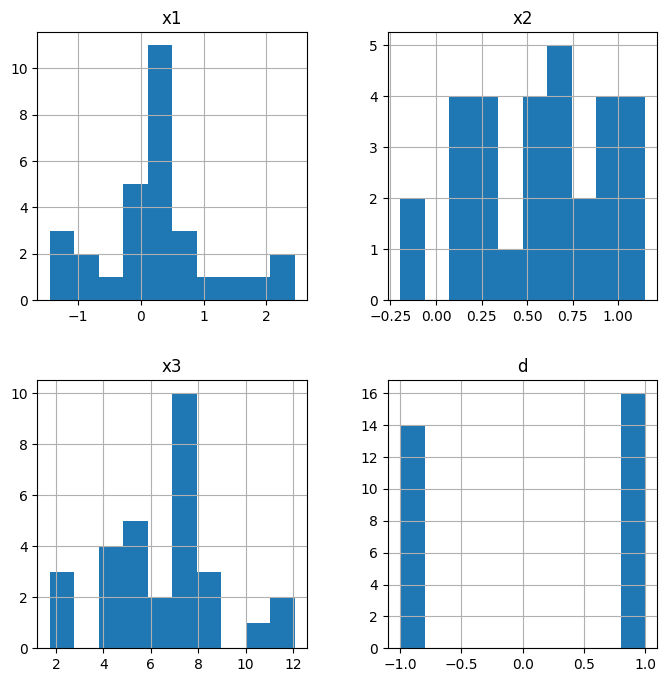

In [ ]:
df.columns = ['x1', 'x2', 'x3', 'd'] # renomeando colunas
df.hist(figsize=(8,8))

In [ ]:
X = df[['x1', 'x2', 'x3']] # Features
y = df['d'] # Target

# Verificar a distribuição dos dados de target
Counter(df['d'])

Counter({-1: 14, 1: 16})

In [ ]:
# Treinando modelos não sensíveis a escalas

# Árvore de decisão
modelo_tree = DecisionTreeClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=30)
scores_tree = cross_val_score(modelo_tree, X, y, cv=skf, scoring='accuracy')
print('Árvore de Decisão')
print('Acurácia Média: ', scores_tree.mean())
print('Desvio padrão:', scores_tree.std())
print('-'*20)

# Naive Bayes
modelo_nb = GaussianNB()

scores_nb = cross_val_score(modelo_nb, X, y, cv=skf, scoring='accuracy')
print('Naive Bayes')
print('Acurácia Média: ', scores_nb.mean())
print('Desvio padrão:', scores_nb.std())

Árvore de Decisão
Acurácia Média:  0.8
Desvio padrão: 0.16329931618554522
--------------------
Naive Bayes
Acurácia Média:  0.6666666666666667
Desvio padrão: 0.21081851067789198


In [ ]:
# Normalizando escalas e dividindo dados de teste e treino

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', random_state=42)
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=30)

resultados_finais = {nome: [] for nome in modelos.keys()}

# Treinando modelos sensíveis a escadlas
for fold, (indices_treino, indices_teste) in enumerate(kfold.split(X, y), 1):
    #print(f"Fold {fold}") -> conferir o número de folds
    # Separar os dados de treino e teste deste fold
    X_treino, X_teste = X[indices_treino], X[indices_teste]
    y_treino, y_teste = y[indices_treino], y[indices_teste]
    # Normalização dos dados de treino apenas
    scaler = MinMaxScaler()
    scaler.fit(X_treino)
    X_treino_norm = scaler.transform(X_treino)
    X_teste_norm = scaler.transform(X_teste)

    # Treinamento dos modelos dentro do loop
    for nome, modelo in modelos.items():
        modelo.fit(X_treino_norm, y_treino)
    # Avaliação dos desempenhos de cada modelo
    for nome, modelo in modelos.items():
        acuracia = modelo.score(X_teste_norm, y_teste)
        resultados_finais[nome].append(acuracia)

print("\nModelo KNN:")
print("Acurácia Média:", sum(resultados_finais["KNN"]) / len(resultados_finais["KNN"]))
print("Desvio Padrão:", np.std(resultados_finais["KNN"]))
print('-'*20)
print("\nModelo SVM:")
print("Acurácia Média:", sum(resultados_finais["SVM"]) / len(resultados_finais["SVM"]))
print("Desvio Padrão:", np.std(resultados_finais["SVM"]))


Modelo KNN:
Acurácia Média: 0.6333333333333333
Desvio Padrão: 0.16329931618554522
--------------------

Modelo SVM:
Acurácia Média: 0.7333333333333333
Desvio Padrão: 0.08164965809277264


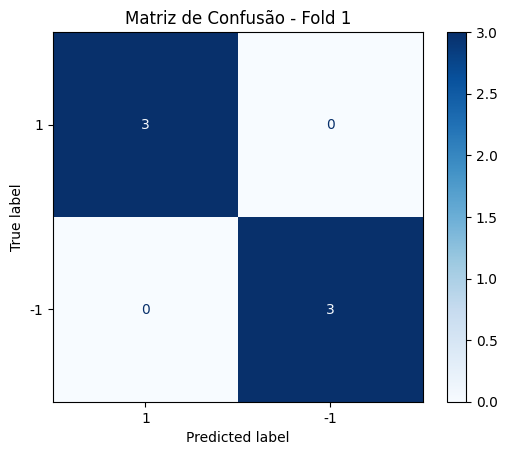

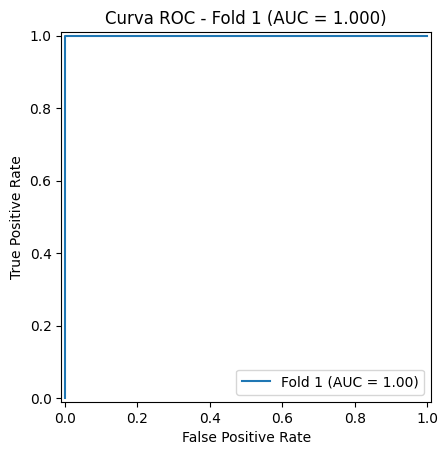

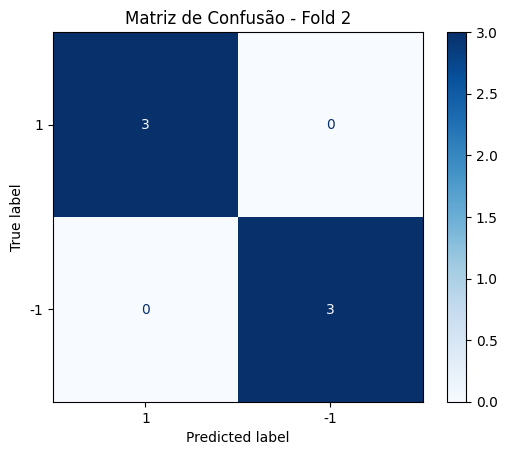

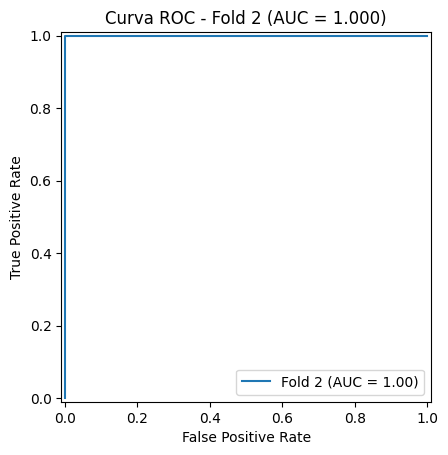

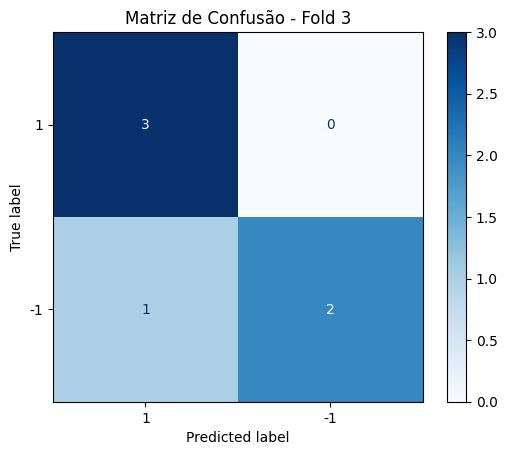

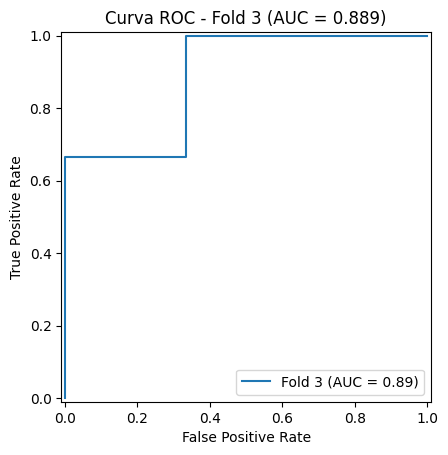

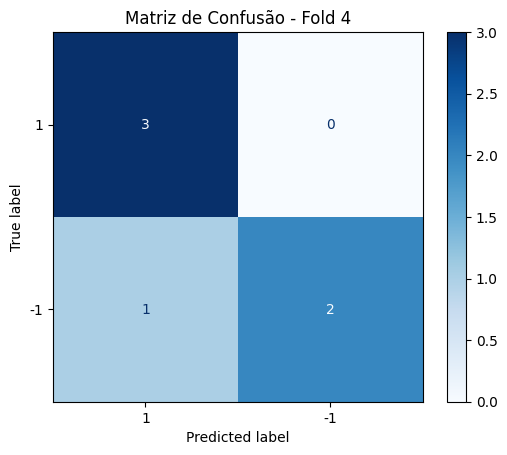

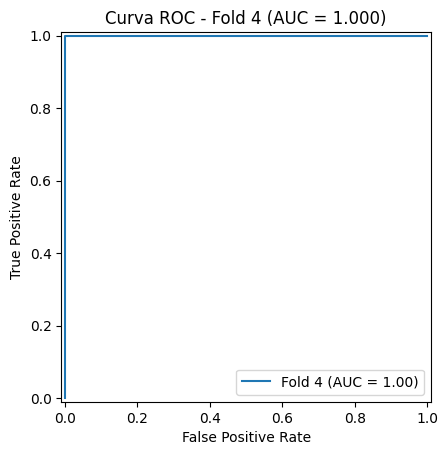

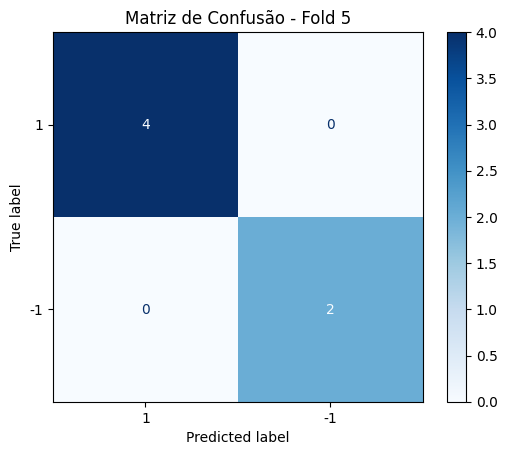

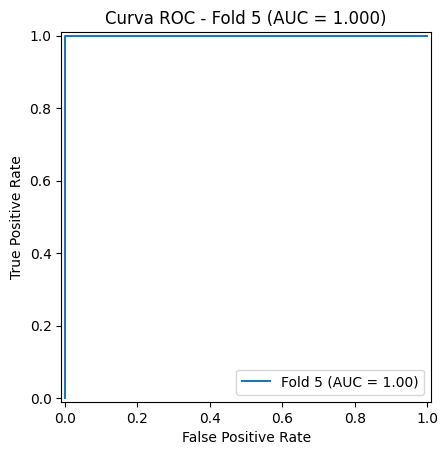

Perceptron

Fold: 1
  Pesos Iniciais: [0.886221, 0.485431, 0.181227, 0.74068]
  Pesos Finais:   [-0.053779, 0.299824, 0.171601, -0.357007]
  Épocas (Treino): 318
  Acurácia (Teste): 100.00%
  Desvios Padrão: Treino=0.0423, Teste=0.0452

Fold: 2
  Pesos Iniciais: [0.556693, 0.845674, 0.31773, 0.697033]
  Pesos Finais:   [-0.043307, 0.261272, 0.150428, -0.317293]
  Épocas (Treino): 92
  Acurácia (Teste): 100.00%
  Desvios Padrão: Treino=0.0380, Teste=0.0362

Fold: 3
  Pesos Iniciais: [0.835614, 0.814242, 0.818835, 0.305583]
  Pesos Finais:   [-0.084386, 0.363242, 0.219314, -0.390513]
  Épocas (Treino): 29
  Acurácia (Teste): 83.33%
  Desvios Padrão: Treino=0.0526, Teste=0.0550

Fold: 4
  Pesos Iniciais: [0.293877, 0.888076, 0.606691, 0.070987]
  Pesos Finais:   [-0.066123, 0.416939, 0.259575, -0.538476]
  Épocas (Treino): 19
  Acurácia (Teste): 83.33%
  Desvios Padrão: Treino=0.0706, Teste=0.0400

Fold: 5
  Pesos Iniciais: [0.515612, 0.852825, 0.590084, 0.125387]
  Pesos Finais:   [-0.08

In [ ]:
# --- Função de Previsão ---
def predict_perceptron(X, w):
    """Faz previsões (1 ou -1) para um conjunto de dados X usando pesos w."""
    net_input = np.dot(X, w)
    y_pred = np.where(net_input >= 0, 1, -1)
    return y_pred, net_input

# --- Parâmetros ---
learning_rate = 0.01
n_splits = 5
max_epochs = 1000

feature_cols = ['x1', 'x2', 'x3']
target_col = 'd'

# --- Normalização ---
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df[feature_cols]), columns=feature_cols)
df_normalized.insert(0, 'bias', 1.0)

X_com_bias = df_normalized.values
X_sem_bias = df[feature_cols].values
d = df[target_col].values

# --- Cross-Validation ---
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results_list = []
accuracies = []
std_devs_train = []
std_devs_test = []

# --- Treinamento e Avaliação ---
for fold, (train_index, test_index) in enumerate(skf.split(X_sem_bias, d)):

    X_train, X_test = X_com_bias[train_index], X_com_bias[test_index]
    d_train, d_test = d[train_index], d[test_index]

    n_features = X_train.shape[1]
    w_initial = np.random.rand(n_features)
    w = w_initial.copy()

    epochs = 0

    # --- Treinamento ---
    while True:
        epochs += 1
        errors_in_epoch = 0

        for i in range(X_train.shape[0]):
            x_vec = X_train[i]
            d_target = d_train[i]

            net_input = np.dot(w, x_vec)
            y_pred = 1 if net_input >= 0 else -1

            error = d_target - y_pred
            if error != 0:
                errors_in_epoch += 1
                w += learning_rate * error * x_vec

        if errors_in_epoch == 0 or epochs >= max_epochs:
            break

    w_final = w

    # --- Avaliação ---
    y_pred_test, net_inputs_test = predict_perceptron(X_test, w_final)
    accuracy = accuracy_score(d_test, y_pred_test)

    # Calcular desvio padrão das saídas (net_input)
    net_inputs_train = np.dot(X_train, w_final)
    std_dev_train = np.std(net_inputs_train)
    std_dev_test = np.std(net_inputs_test)

    accuracies.append(accuracy)
    std_devs_train.append(std_dev_train)
    std_devs_test.append(std_dev_test)

    status_epoca = epochs if errors_in_epoch == 0 else f"Não convergiu em {max_epochs} épocas"

    results_list.append({
        'Fold': fold + 1,
        'Pesos Iniciais': np.round(w_initial, 6).tolist(),
        'Pesos Finais': np.round(w_final, 6).tolist(),
        'Épocas (Treino)': status_epoca,
        'Acurácia (Teste)': f"{accuracy * 100:.2f}%",
        'Desvios Padrão': {
            'Treino': f"{std_dev_train:.4f}",
            'Teste': f"{std_dev_test:.4f}"
        }
    })

    # --- Plotar Matriz de Confusão ---
    cm = confusion_matrix(d_test, y_pred_test, labels=[1, -1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1', '-1'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Matriz de Confusão - Fold {fold + 1}")
    plt.show()

    # --- Plotar Curva ROC ---
    # Converter os rótulos de {-1, 1} para {0, 1} para compatibilidade
    d_test_bin = np.where(d_test == 1, 1, 0)
    net_inputs_test_scaled = (net_inputs_test - np.min(net_inputs_test)) / (np.max(net_inputs_test) - np.min(net_inputs_test))
    fpr, tpr, _ = roc_curve(d_test_bin, net_inputs_test_scaled)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f"Fold {fold + 1}").plot()
    plt.title(f"Curva ROC - Fold {fold + 1} (AUC = {roc_auc:.3f})")
    plt.show()

# --- Resultados numéricos ---
print('Perceptron\n')
for result in results_list:
    print(f"Fold: {result['Fold']}")
    print(f"  Pesos Iniciais: {result['Pesos Iniciais']}")
    print(f"  Pesos Finais:   {result['Pesos Finais']}")
    print(f"  Épocas (Treino): {result['Épocas (Treino)']}")
    print(f"  Acurácia (Teste): {result['Acurácia (Teste)']}")
    print(f"  Desvios Padrão: Treino={result['Desvios Padrão']['Treino']}, Teste={result['Desvios Padrão']['Teste']}\n")

# --- Estatísticas finais ---
mean_accuracy = np.mean(accuracies)
mean_std_train = np.mean(std_devs_train)
mean_std_test = np.mean(std_devs_test)

print(f"Acurácia Média Final (nos {n_splits} Folds): {mean_accuracy * 100:.2f}%")
print(f"Desvio Padrão Médio (Treino): {mean_std_train:.4f}")
print(f"Desvio Padrão Médio (Teste):  {mean_std_test:.4f}")


In [ ]:
# Carregar novas amostras
df_new = pd.read_excel('/content/novas_amostras.xlsx')

# Normalizar as novas amostras usando o scaler ajustado nos dados de treino originais
new_data_normalized_features = scaler.transform(df_new[feature_cols])

# Adicionar a coluna de bias (valor 1.0) às novas amostras normalizadas
# O Perceptron treinado espera a entrada de bias
X_new_processed = np.insert(new_data_normalized_features, 0, 1.0, axis=1)

# Preparar DataFrame para armazenar os resultados
results_df = df_new[['Amostra']].copy()

print("Classificando novas amostras usando os pesos finais de cada Fold do Perceptron\n")

# Aplicar cada modelo (cada vetor de pesos) às novas amostras
for i, result in enumerate(results_list):
    # Extrair os pesos finais do dicionário de resultados
    w_final = result['Pesos Finais']

    # Fazer previsões no conjunto de NOVAS AMOSTRAS usando os pesos finais
    # A função predict_perceptron retorna uma tupla (y_pred, net_input), precisamos apenas de y_pred
    y_predictions_new = predict_perceptron(X_new_processed, w_final)[0] # Acessa o primeiro elemento da tupla

    # Adicionar ao DataFrame de resultados
    results_df[f'Saída Fold {i+1}'] = y_predictions_new

# --- Parte 3: Apresentar Resultados ---
# Usar .to_string(index=False) para uma formatação de tabela limpa
print(results_df.to_string(index=False))

Classificando novas amostras usando os pesos finais de cada Fold do Perceptron

 Amostra  Saída Fold 1  Saída Fold 2  Saída Fold 3  Saída Fold 4  Saída Fold 5
       1            -1            -1            -1            -1            -1
       2             1             1             1             1             1
       3             1             1             1             1             1
       4             1             1             1             1             1
       5             1             1             1             1             1
       6             1             1             1             1             1
       7            -1            -1            -1            -1            -1
       8             1             1             1             1             1
       9            -1            -1            -1            -1            -1
      10            -1            -1            -1            -1            -1


O número de épocas de treinamento para o Perceptron pode variar cada vez que o código de treinamento é excutado devido a: inicialização aleatória dos pesos, pois se os pesos iniciais estiverem mais próximos de uma boa solução, ele pode convergir mais rapidamente, exigindo menos épocas, e o mesmo vale para pesos mais distantes, exigindo mais épocas; a ordem em que as amostras classificadas incorretamente são encontradas pode influenciar como os pesos são atualizados e, consequentemente, o número de épocas necessárias para a convergência; e, a complexidade de separação linear ou não dos dados, ou seja, como os dados estão distribuídos e separados.

A principal limitação do Perceptron, quando aplicado em problemas de classificação de padrões, é que ele só consegue classificar problemas que são linearmente separáveis. Logo, ele só funciona bem quando é possível traçar uma linha reta (ou um hiperplano) que separa completamente as diferentes classes de dados. Se os dados não puderem ser separados por uma linha reta, o Perceptron simples não conseguirá encontrar uma solução e não irá convergir.



###Conclusão

Analisando as métricas de desempenho dos modelos treinados, temos:

- Árvore de Decisão: Acurácia Média: 0.8, Desvio padrão: 0.1633  
- Naive Bayes: Acurácia Média: 0.6667, Desvio padrão: 0.2108  
- KNN: Acurácia Média: 0.6333, Desvio Padrão: 0.1633  
- SVM: Acurácia Média: 0.7333, Desvio Padrão: 0.0816  
- Perceptron: Acurácia Média Final: 0.9333, Desvio Padrão Médio (Teste): 0.0485  

Com base nessas métricas, o Perceptron apresenta a maior acurácia média e o menor desvio padrão médio entre todos os modelos testados. Isso sugere que o Perceptron não apenas teve o melhor desempenho geral na classificação dos dados de teste (alta acurácia), mas também demonstrou a maior consistência em seus resultados entre os diferentes folds da validação cruzada (baixo desvio padrão), indicando que o modelo é robusto e generaliza bem para dados não vistos.
